<a href="https://colab.research.google.com/github/DanielMasierra/Alura_Store_Latam_Challenge/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [17]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()
tienda2.head()
tienda3.head()
print(tienda.shape,tienda2.shape,tienda3.shape,tienda4.shape)
tienda.columns
tienda.dtypes

(2359, 12) (2359, 12) (2359, 12) (2358, 12)


,0
Producto,object
Categoría del Producto,object
Precio,float64
Costo de envío,float64
Fecha de Compra,object
Vendedor,object
Lugar de Compra,object
Calificación,int64
Método de pago,object
Cantidad de cuotas,int64


#**1. Análisis de facturación**


## 1.1 Suma de ingresos por cada tienda

In [18]:
ingreso_t1 = tienda['Precio'].sum()
ingreso_t2 = tienda2['Precio'].sum()
ingreso_t3 = tienda3['Precio'].sum()
ingreso_t4 = tienda4['Precio'].sum()

ingreso_t1, ingreso_t2, ingreso_t3, ingreso_t4

(np.float64(1150880400.0),
 np.float64(1116343500.0),
 np.float64(1098019600.0),
 np.float64(1038375700.0))

##1.2 Ingresos por tienda

In [19]:
ingresos = pd.Series(
    {"tienda_1": ingreso_t1, "tienda_2": ingreso_t2, "tienda_3": ingreso_t3, "tienda_4": ingreso_t4}
).sort_values(ascending=False)

ingresos
ingresos.map(lambda x: f"${x:,.0f}")

,0
tienda_1,"$1,150,880,400"
tienda_2,"$1,116,343,500"
tienda_3,"$1,098,019,600"
tienda_4,"$1,038,375,700"


# 2. Ventas por categoría

En este debes calcular la cantidad de productos vendidos por categoría en cada tienda. La idea es agrupar los datos por categoría y contar el número de ventas de cada tipo, mostrando las categorías más populares de cada tienda.

In [20]:
tienda.columns

Index(['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío',
       'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación',
       'Método de pago', 'Cantidad de cuotas', 'lat', 'lon'],
      dtype='object')

In [21]:
tienda["Categoría del Producto"].unique()[:10]

array(['Electrónicos', 'Muebles', 'Juguetes', 'Electrodomésticos',
       'Artículos para el hogar', 'Deportes y diversión', 'Libros',
       'Instrumentos musicales'], dtype=object)

In [22]:
conteo_cat_tienda1 = tienda["Categoría del Producto"].value_counts()
conteo_cat_tienda1.head(10)

,count
Categoría del Producto,
Muebles,465
Electrónicos,448
Juguetes,324
Electrodomésticos,312
Deportes y diversión,284
Instrumentos musicales,182
Libros,173
Artículos para el hogar,171


In [23]:
conteo_cat_tienda1 = tienda["Categoría del Producto"].value_counts()
conteo_cat_tienda2 = tienda2["Categoría del Producto"].value_counts()
conteo_cat_tienda3 = tienda3["Categoría del Producto"].value_counts()
conteo_cat_tienda4 = tienda4["Categoría del Producto"].value_counts()

conteo_cat_tienda1.head(10), conteo_cat_tienda2.head(10),conteo_cat_tienda3.head(10),conteo_cat_tienda4.head(10)

(Categoría del Producto
 Muebles                    465
 Electrónicos               448
 Juguetes                   324
 Electrodomésticos          312
 Deportes y diversión       284
 Instrumentos musicales     182
 Libros                     173
 Artículos para el hogar    171
 Name: count, dtype: int64,
 Categoría del Producto
 Muebles                    442
 Electrónicos               422
 Juguetes                   313
 Electrodomésticos          305
 Deportes y diversión       275
 Instrumentos musicales     224
 Libros                     197
 Artículos para el hogar    181
 Name: count, dtype: int64,
 Categoría del Producto
 Muebles                    499
 Electrónicos               451
 Juguetes                   315
 Electrodomésticos          278
 Deportes y diversión       277
 Libros                     185
 Instrumentos musicales     177
 Artículos para el hogar    177
 Name: count, dtype: int64,
 Categoría del Producto
 Muebles                    480
 Electrónicos       

# 3. Calificación promedio de la tienda


En este paso, debes calcular las calificaciones promedio de los clientes para cada tienda. El objetivo es conocer la satisfacción del cliente con los productos vendidos.

In [24]:
tienda.head()
tienda.dtypes

,0
Producto,object
Categoría del Producto,object
Precio,float64
Costo de envío,float64
Fecha de Compra,object
Vendedor,object
Lugar de Compra,object
Calificación,int64
Método de pago,object
Cantidad de cuotas,int64


In [25]:
tienda.columns

Index(['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío',
       'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación',
       'Método de pago', 'Cantidad de cuotas', 'lat', 'lon'],
      dtype='object')

In [26]:
promedio_t1 = tienda["Calificación"].mean()
promedio_t2 = tienda2["Calificación"].mean()
promedio_t3 = tienda3["Calificación"].mean()
promedio_t4 = tienda4["Calificación"].mean()
promedio_t1, promedio_t2, promedio_t3, promedio_t4

(np.float64(3.976685036032217),
 np.float64(4.037303942348453),
 np.float64(4.048325561678677),
 np.float64(3.9957591178965224))

In [28]:
calificacion_tiendas = pd.Series(
    {"tienda_1": promedio_t1, "tienda_2": promedio_t2, "tienda_3": promedio_t3, "tienda_4": promedio_t4}
).sort_values(ascending=False)
calificacion_tiendas

,0
tienda_3,4.048326
tienda_2,4.037304
tienda_4,3.995759
tienda_1,3.976685


# 4. Productos más y menos vendidos

En este paso, debes identificar qué productos fueron los más vendidos y los menos vendidos en cada tienda. Visualiza los resultados para que quede claro qué productos destacaron en ventas en cada tienda.

In [ ]:
ventas_producto_t1 = tienda["Producto"].value_counts()


In [30]:
ventas_producto_t1 = tienda["Producto"].value_counts()
ventas_producto_t2 = tienda2["Producto"].value_counts()
ventas_producto_t3 = tienda3["Producto"].value_counts()
ventas_producto_t4 = tienda4["Producto"].value_counts()

ventas_producto_t1





,count
Producto,
Microondas,60
TV LED UHD 4K,60
Armario,60
Secadora de ropa,58
Mesa de noche,56
Bloques de construcción,56
Balón de baloncesto,55
Bicicleta,54
Vaso térmico,54


In [32]:
primeros_10_t1 = ventas_producto_t1.head(10)
primeros_10_t2 = ventas_producto_t2.head(10)
primeros_10_t3 = ventas_producto_t2.head(10)
primeros_10_t4 = ventas_producto_t4.head(10)

In [33]:
ultimos_10_t1 = ventas_producto_t1.tail(10)
ultimos_10_t2 = ventas_producto_t2.tail(10)
ultimos_10_t3 = ventas_producto_t3.tail(10)
ultimos_10_t4 = ventas_producto_t4.tail(10)

<Axes: title={'center': 'Top 10 productos más vendidos – Tienda 1'}, ylabel='Producto'>

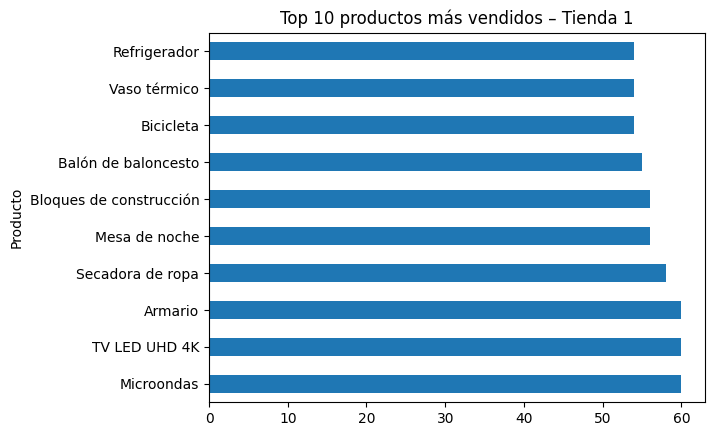

In [43]:
primeros_10_t1.plot(kind="barh", title="Top 10 productos más vendidos – Tienda 1")


<Axes: title={'center': 'Top 10 productos más vendidos – Tienda 2'}, ylabel='Producto'>

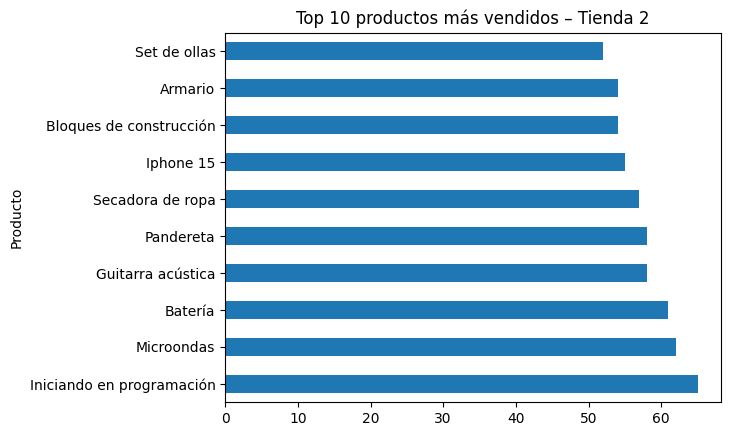

In [42]:
primeros_10_t2.plot(kind="barh", title="Top 10 productos más vendidos – Tienda 2")

<Axes: title={'center': 'Top 10 productos más vendidos – Tienda 3'}, ylabel='Producto'>

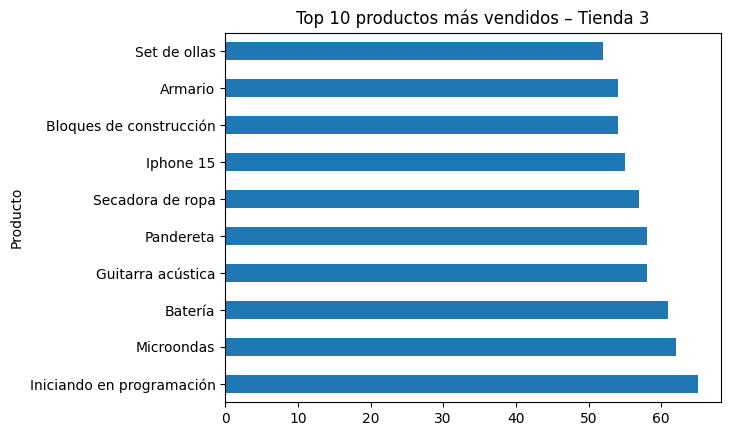

In [44]:
primeros_10_t3.plot(kind="barh", title="Top 10 productos más vendidos – Tienda 3")

<Axes: title={'center': 'Top 10 productos más vendidos – Tienda 4'}, ylabel='Producto'>

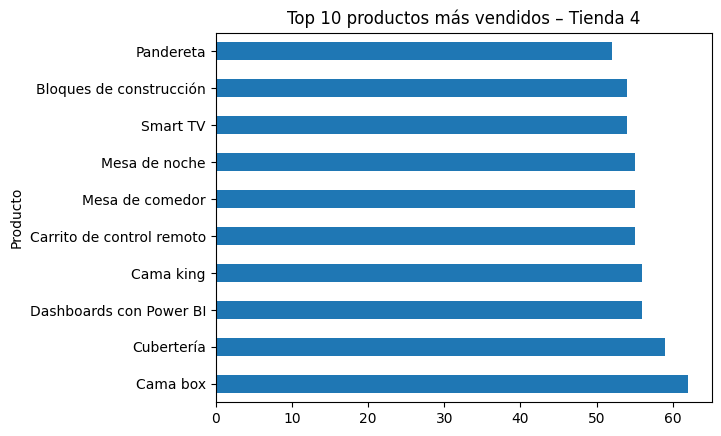

In [45]:

primeros_10_t4.plot(kind="barh", title="Top 10 productos más vendidos – Tienda 4")

<Axes: title={'center': 'Top 10 productos menos vendidos – Tienda 1'}, ylabel='Producto'>

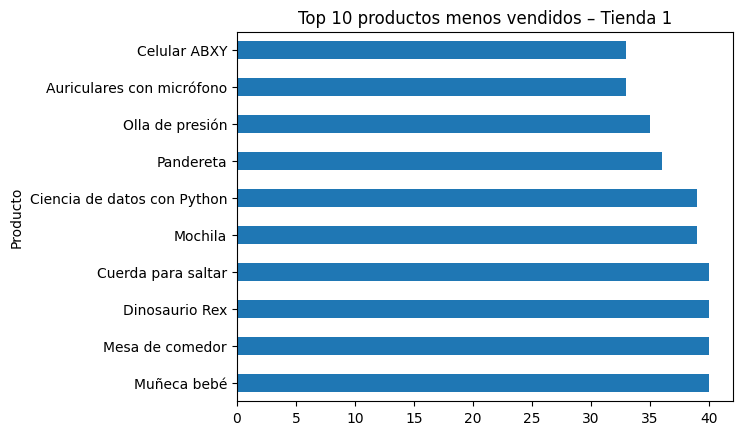

In [46]:
ultimos_10_t1.plot(kind="barh", title="Top 10 productos menos vendidos – Tienda 1")

<Axes: title={'center': 'Top 10 productos menos vendidos – Tienda 2'}, ylabel='Producto'>

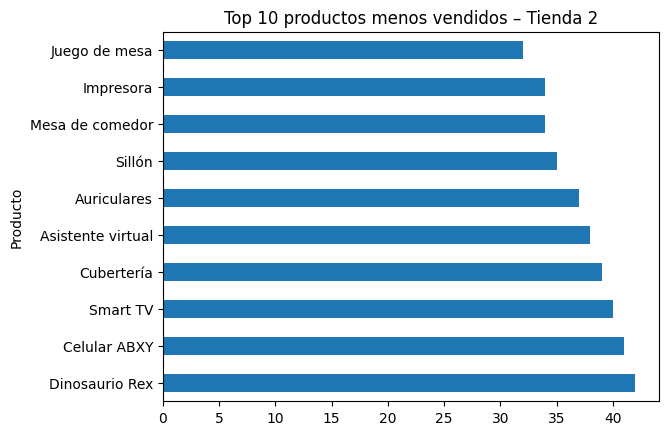

In [47]:
ultimos_10_t2.plot(kind="barh", title="Top 10 productos menos vendidos – Tienda 2")

<Axes: title={'center': 'Top 10 productos menos vendidos – Tienda 3'}, ylabel='Producto'>

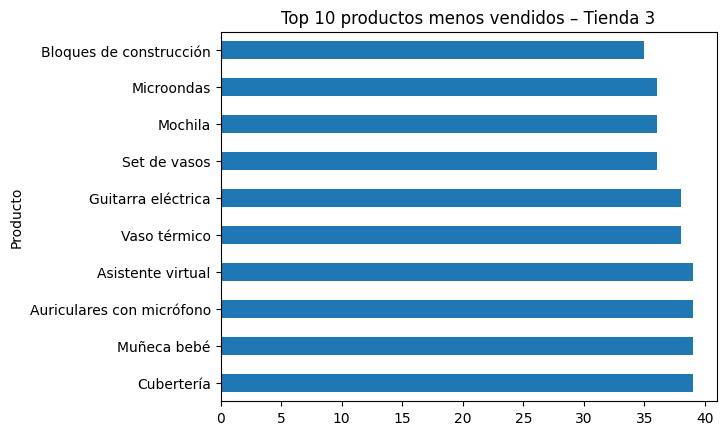

In [48]:
ultimos_10_t3.plot(kind="barh", title="Top 10 productos menos vendidos – Tienda 3")

<Axes: title={'center': 'Top 10 productos menos vendidos – Tienda 4'}, ylabel='Producto'>

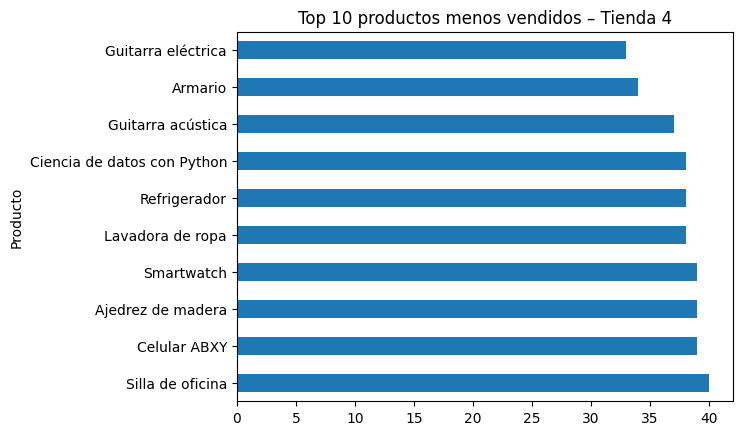

In [49]:
ultimos_10_t4.plot(kind="barh", title="Top 10 productos menos vendidos – Tienda 4")

# 5. Envío promedio por tienda

En este paso, debes calcular el costo de envío promedio para cada tienda. El objetivo es comprender cuánto se gasta, en promedio, en el envío de cada tienda.  Sabiendo que el cliente paga el envío.

In [50]:
envio_promedio_t1 = tienda["Costo de envío"].mean()
envio_promedio_t1

np.float64(26018.60958033065)

In [51]:
envio_prom_t1 = tienda["Costo de envío"].mean()
envio_prom_t2 = tienda2["Costo de envío"].mean()
envio_prom_t3 = tienda3["Costo de envío"].mean()
envio_prom_t4 = tienda4["Costo de envío"].mean()


In [56]:
envios_prom = pd.Series(
    {
        "tienda_1": envio_prom_t1,
        "tienda_2": envio_prom_t2,
        "tienda_3": envio_prom_t3,
        "tienda_4": envio_prom_t4
    }
).sort_values()

envios_prom


,0
tienda_4,23459.457167
tienda_3,24805.680373
tienda_2,25216.235693
tienda_1,26018.609580


In [55]:
envios_prom.map(lambda x: f"${x:,.2f}")


,0
tienda_4,"$23,459.46"
tienda_3,"$24,805.68"
tienda_2,"$25,216.24"
tienda_1,"$26,018.61"


#Generando Gráfico

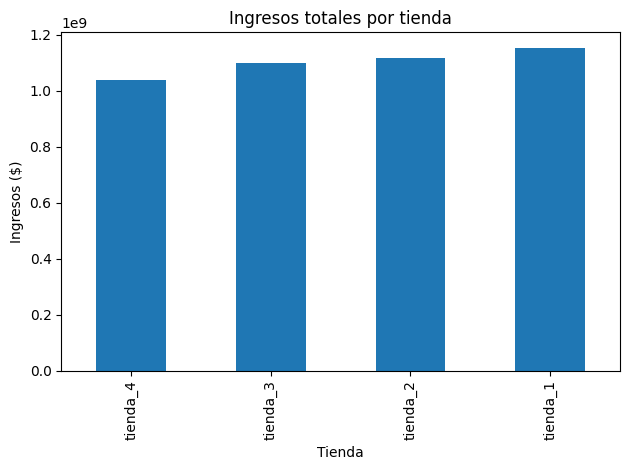

In [57]:
#Ingresos totales por tienda

import matplotlib.pyplot as plt

ax = ingresos.sort_values().plot(kind="bar", title="Ingresos totales por tienda")
ax.set_xlabel("Tienda")
ax.set_ylabel("Ingresos ($)")
plt.tight_layout()
plt.show()


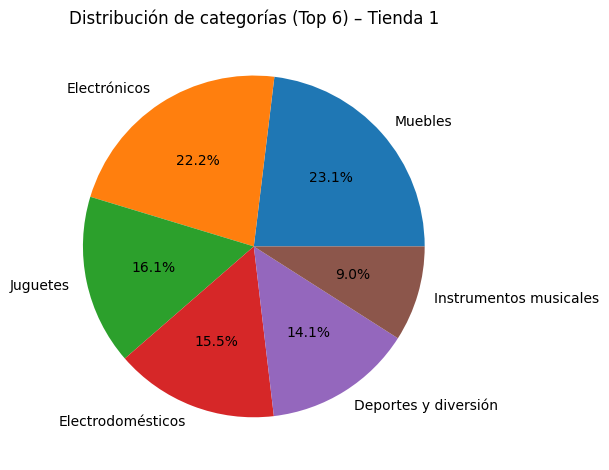

In [58]:
#Top 6 de distribución de categorías - Tienda 1

cat_t1 = tienda["Categoría del Producto"].value_counts().head(6)

plt.figure()
plt.pie(cat_t1.values, labels=cat_t1.index, autopct="%1.1f%%")
plt.title("Distribución de categorías (Top 6) – Tienda 1")
plt.tight_layout()
plt.show()


#¿Qué tendría que vender el señor Juan en sus tiendas?

1. Introducción

El objetivo de este análisis fue comparar el desempeño de las cuatro tiendas de Alura Store para recomendar cuál debería vender el Sr. Juan. Para ello se evaluaron ingresos totales, calificación promedio de clientes, productos con menor desempeño y costo promedio de envío, complementando el análisis con visualizaciones para facilitar la interpretación.

Desarrollo

Ingresos totales. La tienda con mayores ingresos fue la tienda 1 con $1,150,880,400, seguida por tienda 2 y tienda 3. La tienda 4 registró el menor ingreso total con $1,038,375,700. En el gráfico de barras de ingresos se observa que tienda 4 se mantiene consistentemente por debajo del resto, por lo que aporta menos al resultado global del negocio.

Satisfacción del cliente (calificación promedio). Las mejores calificaciones promedio corresponden a tienda 3 (4.048) y tienda 2 (4.037). La tienda 4 se mantiene cercana (3.996), mientras que tienda 1 presenta la calificación más baja (3.977). Esto sugiere que tienda_1, aunque vende más, enfrenta mayor área de mejora en percepción del cliente.

Costo promedio de envío. La tienda 4 tiene el costo de envío promedio más bajo ($23,459.46), seguida por tienda 3 y tienda 2. La tienda_1 tiene el envío promedio más alto ($26,018.61). Aunque el envío lo paga el cliente, un costo más alto puede representar fricción y afectar conversión, por lo que esta métrica ayuda a entender diferencias de experiencia de compra.

Productos menos vendidos. En los gráficos de “Top 10 productos menos vendidos” por tienda se observan productos de baja rotación en todas las tiendas, lo cual es normal en catálogos amplios. Estos gráficos ayudan a evidenciar que cada tienda tiene un conjunto de artículos con desempeño débil y que el rendimiento no depende solo de unos cuantos productos.

Conclusión y recomendación

Con base en los resultados, se recomienda que el Sr. Juan venda la tienda 4. La razón principal es que es la tienda con menor ingreso total ($1,038,375,700), lo que indica que es la que menos aporta a la cadena en términos de ventas. Aunque su costo de envío promedio es el más bajo y su calificación promedio es aceptable, el criterio de eficiencia global favorece conservar las tiendas con mejor desempeño en ingresos. Por lo tanto, vender tienda 4 representa el menor costo de oportunidad para financiar el nuevo emprendimiento.
